# ListenBrainz Popularity Prediction

Predict which artists and tracks will reach **≥95th growth percentile** over upcoming 7-day and 30-day windows.

**Models**: XGBoost (classification + regression) and LSTM (PyTorch)  
**Data**: RDS Postgres → PySpark feature engineering → pandas → model training  
**Scope**: Separate artist and track models

| Phase | Description |
|-------|-------------|
| 1 | Data loading & feature engineering (Spark JDBC) |
| 2 | XGBoost classifier + regressor |
| 3 | LSTM sequence model (PyTorch) |
| 4 | Evaluation & comparison |

**Before running, make sure:**

- SSH tunnel is active (localhost:5433 → RDS)
- .env has fresh AWS credentials
- Required packages are installed: xgboost, shap, torch, scikit-learn, matplotlib

In [114]:
import importlib
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Add parent dir so we can import project modules
sys.path.insert(0, str(Path.cwd().parent))

import utils
importlib.reload(utils)
from utils import load_db_credentials

print("Imports OK")

Imports OK


In [115]:
from dotenv import load_dotenv
import json

import psycopg2
import boto3

env_path = Path.cwd().parent.parent / ".env"
print(f"Loading env from: {env_path}  (exists={env_path.exists()})")
load_dotenv(dotenv_path=env_path, override=True)

# Reset boto3 session so it picks up fresh env vars
boto3.DEFAULT_SESSION = None

creds = load_db_credentials()


def _probe_db(c):
    conn = None
    try:
        conn = psycopg2.connect(
            host=c["host"],
            port=int(c["port"]),
            dbname=c["dbname"],
            user=c["user"],
            password=c["password"],
            connect_timeout=6,
            sslmode="prefer",
        )
        with conn.cursor() as cur:
            cur.execute("SELECT current_user, current_database();")
            current_user, current_db = cur.fetchone()
        return True, f"connected as {current_user} to {current_db}"
    except Exception as e:
        return False, str(e)
    finally:
        if conn is not None:
            conn.close()


def _candidate_creds(base):
    candidates = [dict(base)]
    is_loopback = str(base["host"]).strip('"') in {"127.0.0.1", "localhost"}

    # Common local setup uses an SSH tunnel on 5433.
    if is_loopback and int(base["port"]) == 5432:
        alt = dict(base)
        alt["port"] = 5433
        candidates.append(alt)

    # If secret includes username, try it as a fallback.
    secret_username = None
    try:
        sm = boto3.client("secretsmanager", region_name=utils._AWS_REGION)
        secret_str = sm.get_secret_value(SecretId=utils._SECRET_ARN)["SecretString"]
        secret_obj = json.loads(secret_str)
        secret_username = secret_obj.get("username") or secret_obj.get("user")
    except Exception:
        pass

    if secret_username and secret_username != base["user"]:
        alt_user = dict(base)
        alt_user["user"] = secret_username
        candidates.append(alt_user)

        if is_loopback and int(base["port"]) == 5432:
            alt_user_port = dict(alt_user)
            alt_user_port["port"] = 5433
            candidates.append(alt_user_port)

    deduped = []
    seen = set()
    for c in candidates:
        key = (str(c["host"]), int(c["port"]), str(c["dbname"]), str(c["user"]))
        if key not in seen:
            seen.add(key)
            deduped.append(c)
    return deduped


selected = None
errors = []
for cand in _candidate_creds(creds):
    ok, msg = _probe_db(cand)
    if ok:
        selected = cand
        print(
            f"DB probe OK: {cand['host']}:{cand['port']}/{cand['dbname']} "
            f"as {cand['user']} ({msg})"
        )
        break
    errors.append(
        f"{cand['host']}:{cand['port']}/{cand['dbname']} as {cand['user']} -> {msg}"
    )

if selected is None:
    print("Database probe failed for all candidate credentials:")
    for err in errors:
        print(f"  - {err}")

    hints = []
    if any("127.0.0.1:5433" in err and "Connection refused" in err for err in errors):
        hints.append("Start your SSH tunnel to RDS on local port 5433.")
    if any('role "postgres" does not exist' in err for err in errors):
        hints.append("Set PGUSER in project/.env to a valid role for this DB.")

    # Ensure stale Spark state from prior runs cannot leak into later cells.
    try:
        old_spark = globals().get("spark", None)
        if old_spark is not None:
            old_spark.stop()
    except Exception:
        pass
    spark = None

    creds = None
    raise RuntimeError(
        "Could not authenticate to Postgres. " + " ".join(hints)
    )

creds = selected
print(f"Using DB: {creds['host']}:{creds['port']}/{creds['dbname']} as {creds['user']}")

Loading env from: /Users/didiermunezero/Documents/NU/Junior/DE 300/de300-2026wi-stall/project/.env  (exists=True)
DB probe OK: 127.0.0.1:5432/newsfeed as newsfeed (connected as newsfeed to newsfeed)
Using DB: 127.0.0.1:5432/newsfeed as newsfeed


## Phase 1 — Data Loading & Feature Engineering

Load `artist_daily_stats` / `track_daily_stats` joined with raw listen counts via Spark JDBC, engineer momentum/velocity/lag features, build forward-looking target labels, and convert to pandas with a temporal train/test split.

In [116]:
import os

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark import SparkContext

if not globals().get("creds"):
    raise RuntimeError("Run Cell 4 successfully first so valid DB credentials are loaded into `creds`.")


def _reset_spark_state():
    """Clear stale Spark/Py4J state so getOrCreate can start a fresh JVM."""
    try:
        old_spark = globals().get("spark", None)
        if old_spark is not None:
            old_spark.stop()
    except Exception:
        pass

    # Drop static Spark session/context pointers.
    SparkSession._instantiatedSession = None
    SparkSession._activeSession = None
    SparkContext._active_spark_context = None

    # Drop dead Py4J gateway/jvm handles so Spark can relaunch them.
    gateway = getattr(SparkContext, "_gateway", None)
    if gateway is not None:
        try:
            gateway.close()
        except Exception:
            pass
    SparkContext._gateway = None
    SparkContext._jvm = None

    # If these are set, PySpark will try to reconnect to a fixed (possibly dead) gateway port.
    os.environ.pop("PYSPARK_GATEWAY_PORT", None)
    os.environ.pop("PYSPARK_GATEWAY_SECRET", None)


def _build_spark_session():
    return (
        SparkSession.builder
        .master("local[*]")
        .appName("ListenBrainz Popularity")
        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.1")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.session.timeZone", "UTC")
        .getOrCreate()
    )


_reset_spark_state()
spark = _build_spark_session()

jdbc_url = f"jdbc:postgresql://{creds['host']}:{creds['port']}/{creds['dbname']}"
jdbc_props = {
    "user": creds["user"],
    "password": creds["password"],
    "driver": "org.postgresql.Driver",
}

print(
    f"Spark {spark.version} ready — JDBC -> "
    f"{creds['host']}:{creds['port']}/{creds['dbname']} as {creds['user']}"
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/08 01:09:16 WARN Utils: Your hostname, Didiers-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.220 instead (on interface en0)
26/03/08 01:09:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/opt/homebrew/anaconda3/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/didiermunezero/.ivy2.5.2/cache
The jars for the packages stored in: /Users/didiermunezero/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-989986a0-45d4-4e08-b4f8-22b5def9e9a5;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.1 in central
	found org.checkerframework#checker-qual;3.41.0 in central
:: resolution report :: resolve 96ms :: artifacts dl 4ms
	:: modules in use:
	org.check

Spark 4.1.1 ready — JDBC -> 127.0.0.1:5432/newsfeed as newsfeed


In [117]:
def load_and_engineer(spark, jdbc_url, jdbc_props, stats_table, listens_table, id_col):
    """
    Load stats + daily listens from Postgres, join, and engineer features.
    Returns a Spark DataFrame with all original + new columns.
    """
    stats = spark.read.jdbc(url=jdbc_url, table=stats_table, properties=jdbc_props)
    listens = spark.read.jdbc(url=jdbc_url, table=listens_table, properties=jdbc_props)
    print(f"Loaded {stats.count():,} rows from {stats_table}, {listens.count():,} from {listens_table}")

    # Join to get raw listen_count alongside precomputed stats
    df = stats.join(listens, on=["day", id_col], how="inner")

    # Windows for additional features
    w_id = Window.partitionBy(id_col).orderBy("day")
    w_id_7 = w_id.rowsBetween(-6, 0)
    w_id_30 = w_id.rowsBetween(-29, 0)
    w_first = Window.partitionBy(id_col)

    df = (
        df
        # Momentum: short-term acceleration
        .withColumn("_7d_lag7", F.lag("listen_count_past_7_days", 7).over(w_id))
        .withColumn("momentum_7d", F.col("listen_count_past_7_days") - F.col("_7d_lag7"))
        .withColumn("_30d_lag30", F.lag("listen_count_past_30_days", 30).over(w_id))
        .withColumn("momentum_30d", F.col("listen_count_past_30_days") - F.col("_30d_lag30"))
        # Velocity ratio: short-term vs long-term activity
        .withColumn(
            "velocity_ratio",
            F.when(
                F.col("listen_count_past_30_days") > 0,
                F.col("listen_count_past_7_days") / F.col("listen_count_past_30_days"),
            ).otherwise(None),
        )
        # Lifecycle proxy
        .withColumn("_first_day", F.min("day").over(w_first))
        .withColumn("days_since_first_listen", F.datediff(F.col("day"), F.col("_first_day")))
        # Lag features (for LSTM sequences)
        .withColumn("listen_count_lag_1d", F.lag("listen_count", 1).over(w_id))
        .withColumn("listen_count_lag_7d", F.lag("listen_count", 7).over(w_id))
        # Day of week (0=Mon .. 6=Sun); Spark dayofweek is 1=Sun
        .withColumn("day_of_week", (F.dayofweek("day") + 5) % 7)
        .withColumn("is_weekend", F.when(F.dayofweek("day").isin([1, 7]), 1).otherwise(0))
        # Extra features for better signal quality
        .withColumn("listen_count_ma_7d", F.avg("listen_count").over(w_id_7))
        .withColumn("listen_count_ma_30d", F.avg("listen_count").over(w_id_30))
        .withColumn("listen_count_std_7d", F.stddev_pop("listen_count").over(w_id_7))
        .withColumn("log_listen_count", F.log1p(F.col("listen_count")))
        .withColumn(
            "momentum_ratio_7_30",
            F.col("momentum_7d") / (F.abs(F.col("momentum_30d")) + F.lit(1.0)),
        )
        # Drop helper columns
        .drop("_7d_lag7", "_30d_lag30", "_first_day")
    )

    print(f"Feature-engineered DataFrame: {df.count():,} rows, {len(df.columns)} columns")
    return df

print("load_and_engineer() defined")

load_and_engineer() defined


In [118]:
artist_df = load_and_engineer(
    spark, jdbc_url, jdbc_props,
    "artist_daily_stats", "artist_daily_listens", "artist_mbid",
)
track_df = load_and_engineer(
    spark, jdbc_url, jdbc_props,
    "track_daily_stats", "track_daily_listens", "recording_id",
)

Loaded 18,238 rows from artist_daily_stats, 18,238 from artist_daily_listens
Feature-engineered DataFrame: 18,238 rows, 22 columns


Loaded 2,377,730 rows from track_daily_stats, 2,377,730 from track_daily_listens


Feature-engineered DataFrame: 2,377,730 rows, 22 columns


In [119]:
def add_targets(df, id_col, threshold=0.95, min_future_counts=None):
    """
    Add forward-looking target labels:
      - is_popular_7d / is_popular_30d
      - future_growth_pctl_7d / future_growth_pctl_30d

    `min_future_counts` controls how strict each horizon is, e.g.:
      {"7d": 7, "30d": 30} for strict labels,
      {"7d": 3, "30d": 7} for sparse entities.
    """
    if min_future_counts is None:
        min_future_counts = {"7d": 7, "30d": 30}

    min_7 = int(min_future_counts.get("7d", 7))
    min_30 = int(min_future_counts.get("30d", 30))

    w_id = Window.partitionBy(id_col).orderBy("day")
    w_fwd_7 = w_id.rowsBetween(1, 7)
    w_fwd_30 = w_id.rowsBetween(1, 30)

    # Forward-looking aggregates
    df = (
        df
        .withColumn("_max_gp_7", F.max("growth_percentile").over(w_fwd_7))
        .withColumn("_max_gp_30", F.max("growth_percentile").over(w_fwd_30))
        .withColumn("_mean_gp_7", F.avg("growth_percentile").over(w_fwd_7))
        .withColumn("_mean_gp_30", F.avg("growth_percentile").over(w_fwd_30))
        .withColumn("_fwd_count_7", F.count("growth_percentile").over(w_fwd_7))
        .withColumn("_fwd_count_30", F.count("growth_percentile").over(w_fwd_30))
    )

    # Flexible per-horizon filtering
    df = df.filter((F.col("_fwd_count_7") >= min_7) & (F.col("_fwd_count_30") >= min_30))

    df = (
        df
        .withColumn("is_popular_7d", F.when(F.col("_max_gp_7") >= threshold, 1).otherwise(0))
        .withColumn("is_popular_30d", F.when(F.col("_max_gp_30") >= threshold, 1).otherwise(0))
        .withColumn("future_growth_pctl_7d", F.col("_mean_gp_7"))
        .withColumn("future_growth_pctl_30d", F.col("_mean_gp_30"))
        .drop("_max_gp_7", "_max_gp_30", "_mean_gp_7", "_mean_gp_30", "_fwd_count_7", "_fwd_count_30")
    )

    n = df.count()
    if n == 0:
        print(
            f"After target labeling ({id_col}): 0 rows remain "
            f"(requirements: 7d>={min_7}, 30d>={min_30})."
        )
        return df

    pos_7 = df.filter(F.col("is_popular_7d") == 1).count()
    pos_30 = df.filter(F.col("is_popular_30d") == 1).count()
    print(f"After target labeling ({id_col}): {n:,} rows")
    print(f"  Required future rows -> 7d:>={min_7}, 30d:>={min_30}")
    print(f"  is_popular_7d:  {pos_7:,} positive ({100 * pos_7 / n:.2f}%)")
    print(f"  is_popular_30d: {pos_30:,} positive ({100 * pos_30 / n:.2f}%)")
    return df

print("add_targets() defined")

add_targets() defined


In [120]:
# Artist data is sparse (very short forward horizons), so keep minimal forward requirements.
artist_df = add_targets(
    artist_df,
    "artist_mbid",
    threshold=0.95,
    min_future_counts={"7d": 1, "30d": 1},
)

# Keep stricter horizon requirements for tracks.
track_df = add_targets(
    track_df,
    "recording_id",
    threshold=0.95,
    min_future_counts={"7d": 7, "30d": 30},
)

After target labeling (artist_mbid): 659 rows
  Required future rows -> 7d:>=1, 30d:>=1
  is_popular_7d:  654 positive (99.24%)
  is_popular_30d: 654 positive (99.24%)


After target labeling (recording_id): 467,270 rows
  Required future rows -> 7d:>=7, 30d:>=30
  is_popular_7d:  5,806 positive (1.24%)
  is_popular_30d: 6,426 positive (1.38%)


In [121]:
def _pick_temporal_cutoff(
    pdf,
    target_cols,
    test_days_candidates,
    min_train_rows,
    min_test_rows,
    min_positive_per_target,
):
    """Find the smallest temporal holdout that has enough train rows, test rows, and positives."""
    max_day = pdf["day"].max()
    class_targets = [c for c in target_cols[:2] if c in pdf.columns]

    best_candidate = None
    best_score = (-1, -1, -1)

    for days in test_days_candidates:
        cutoff = max_day - pd.Timedelta(days=int(days))
        train = pdf[pdf["day"] <= cutoff].copy()
        test = pdf[pdf["day"] > cutoff].copy()

        pos_counts = {t: int(test[t].sum()) for t in class_targets}
        min_pos = min(pos_counts.values()) if pos_counts else 0

        meets_train = len(train) >= min_train_rows
        meets_test = len(test) >= min_test_rows
        meets_pos = (min_pos >= min_positive_per_target) if class_targets else True

        candidate = (days, cutoff, train, test, pos_counts, meets_train, meets_test, meets_pos)
        score = (int(meets_train), min_pos, len(test))

        if score > best_score:
            best_candidate = candidate
            best_score = score

        if meets_train and meets_test and meets_pos:
            return candidate, True

    return best_candidate, False


def spark_to_pandas_split(
    sdf,
    id_col,
    test_days_candidates=(30, 60, 90, 120, 180, 270, 365),
    min_train_rows=50000,
    min_test_rows=5000,
    min_positive_per_target=50,
):
    """
    Convert Spark DF to pandas and do a robust temporal split.
    Chooses a holdout window that tries to satisfy minimum train size, test size, and positives.
    Returns (train_pdf, test_pdf, feature_cols, target_cols).
    """
    target_cols = [
        "is_popular_7d",
        "is_popular_30d",
        "future_growth_pctl_7d",
        "future_growth_pctl_30d",
    ]

    pdf = sdf.toPandas()
    if pdf.empty:
        print(f"Warning: {id_col} dataset is empty after target labeling.")
        empty = pd.DataFrame()
        return empty, empty, [], target_cols

    pdf["day"] = pd.to_datetime(pdf["day"])
    pdf = pdf.sort_values(["day", id_col]).reset_index(drop=True)

    selection, constraints_met = _pick_temporal_cutoff(
        pdf,
        target_cols,
        test_days_candidates,
        min_train_rows,
        min_test_rows,
        min_positive_per_target,
    )

    selected_days, cutoff, train, test, pos_counts, meets_train, meets_test, meets_pos = selection

    if constraints_met:
        print(f"Selected test window for {id_col}: last {selected_days} days (constraints met).")
    else:
        print(f"Selected test window for {id_col}: last {selected_days} days (best fallback).")
        print(
            "  Constraints unmet -> "
            f"min_train_rows={min_train_rows}, min_test_rows={min_test_rows}, "
            f"min_positive_per_target={min_positive_per_target}"
        )
        print(
            f"  Observed -> train_rows={len(train):,}, test_rows={len(test):,}, positives={pos_counts}, "
            f"meets_train={meets_train}, meets_test={meets_test}, meets_pos={meets_pos}"
        )

    # Feature columns: everything except id, day, and targets
    exclude = {id_col, "day"} | set(target_cols)
    feature_cols = [
        c
        for c in pdf.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(pdf[c])
    ]

    if train.empty or test.empty:
        print(
            f"Warning: temporal split for {id_col} produced empty train/test "
            f"(train={len(train)}, test={len(test)})."
        )
    else:
        print(f"Train: {len(train):,} rows ({train['day'].min().date()} – {train['day'].max().date()})")
        print(f"Test:  {len(test):,} rows  ({test['day'].min().date()} – {test['day'].max().date()})")
        print(f"Test positives: {pos_counts}")

    print(f"Features ({len(feature_cols)}): {feature_cols}")
    print(f"Targets: {target_cols}")
    return train, test, feature_cols, target_cols

print("spark_to_pandas_split() defined")

spark_to_pandas_split() defined


In [122]:
art_train, art_test, art_features, target_cols = spark_to_pandas_split(
    artist_df,
    "artist_mbid",
    test_days_candidates=(1, 2, 3, 7, 14, 30, 60),
    min_train_rows=200,
    min_test_rows=100,
    min_positive_per_target=5,
)

trk_train, trk_test, trk_features, _ = spark_to_pandas_split(
    track_df,
    "recording_id",
    test_days_candidates=(30, 60, 90, 120, 180, 270, 365),
    min_train_rows=50000,
    min_test_rows=5000,
    min_positive_per_target=50,
)

# Stop Spark and clear cached session/context references for safe notebook reruns.
from pyspark.sql import SparkSession
from pyspark import SparkContext

try:
    spark.stop()
except Exception:
    pass

SparkSession._instantiatedSession = None
SparkSession._activeSession = None
SparkContext._active_spark_context = None
spark = None
print("Spark session stopped and cleared.")

26/03/08 01:10:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Selected test window for artist_mbid: last 2 days (constraints met).
Train: 202 rows (2026-01-23 – 2026-02-10)
Test:  457 rows  (2026-02-11 – 2026-02-12)
Test positives: {'is_popular_7d': 456, 'is_popular_30d': 456}
Features (20): ['growth_percentile', 'cumulative_listen_count', 'listen_count_past_7_days', 'listen_pctl_past_7_days', 'listen_count_past_30_days', 'listen_pctl_past_30_days', 'listen_count', 'momentum_7d', 'momentum_30d', 'velocity_ratio', 'days_since_first_listen', 'listen_count_lag_1d', 'listen_count_lag_7d', 'day_of_week', 'is_weekend', 'listen_count_ma_7d', 'listen_count_ma_30d', 'listen_count_std_7d', 'log_listen_count', 'momentum_ratio_7_30']
Targets: ['is_popular_7d', 'is_popular_30d', 'future_growth_pctl_7d', 'future_growth_pctl_30d']


Selected test window for recording_id: last 365 days (constraints met).
Train: 456,884 rows (2005-02-13 – 2024-12-25)
Test:  10,386 rows  (2024-12-26 – 2025-12-25)
Test positives: {'is_popular_7d': 79, 'is_popular_30d': 90}
Features (20): ['growth_percentile', 'cumulative_listen_count', 'listen_count_past_7_days', 'listen_pctl_past_7_days', 'listen_count_past_30_days', 'listen_pctl_past_30_days', 'listen_count', 'momentum_7d', 'momentum_30d', 'velocity_ratio', 'days_since_first_listen', 'listen_count_lag_1d', 'listen_count_lag_7d', 'day_of_week', 'is_weekend', 'listen_count_ma_7d', 'listen_count_ma_30d', 'listen_count_std_7d', 'log_listen_count', 'momentum_ratio_7_30']
Targets: ['is_popular_7d', 'is_popular_30d', 'future_growth_pctl_7d', 'future_growth_pctl_30d']
Spark session stopped and cleared.


In [123]:
# Quick sanity check: NaN rates and class balance
for name, df in [("Artist Train", art_train), ("Track Train", trk_train)]:
    print(f"\n{'='*40}")
    print(f"{name}  ({len(df):,} rows)")
    
    if len(df) == 0:
        print("  Skipping analysis: empty dataset")
        continue
    
    feat_cols = art_features if 'Artist' in name else trk_features
    if len(feat_cols) > 0:
        print(f"  NaN %: {(df[feat_cols].isna().mean() * 100).round(1).to_dict()}")
    
    for t in target_cols[:2]:  # classification targets
        if t in df.columns:
            pos = df[t].mean()
            print(f"  {t}: {100*pos:.1f}% positive")


Artist Train  (202 rows)
  NaN %: {'growth_percentile': 0.0, 'cumulative_listen_count': 0.0, 'listen_count_past_7_days': 0.0, 'listen_pctl_past_7_days': 0.0, 'listen_count_past_30_days': 0.0, 'listen_pctl_past_30_days': 0.0, 'listen_count': 0.0, 'momentum_7d': 100.0, 'momentum_30d': 100.0, 'velocity_ratio': 0.0, 'days_since_first_listen': 0.0, 'listen_count_lag_1d': 94.6, 'listen_count_lag_7d': 100.0, 'day_of_week': 0.0, 'is_weekend': 0.0, 'listen_count_ma_7d': 0.0, 'listen_count_ma_30d': 0.0, 'listen_count_std_7d': 0.0, 'log_listen_count': 0.0, 'momentum_ratio_7_30': 100.0}
  is_popular_7d: 98.0% positive
  is_popular_30d: 98.0% positive

Track Train  (456,884 rows)
  NaN %: {'growth_percentile': 0.0, 'cumulative_listen_count': 0.0, 'listen_count_past_7_days': 0.0, 'listen_pctl_past_7_days': 0.0, 'listen_count_past_30_days': 0.0, 'listen_pctl_past_30_days': 0.0, 'listen_count': 0.0, 'momentum_7d': 17.2, 'momentum_30d': 51.1, 'velocity_ratio': 0.0, 'days_since_first_listen': 0.0, 'lis

## Phase 2 — XGBoost Models

Train XGBoost classifiers (binary: popular yes/no) and regressors (continuous growth percentile) for both 7-day and 30-day horizons. Temporal expanding-window CV for hyperparameter selection. SHAP for feature importance.

In [124]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import TimeSeriesSplit
import shap

print("XGBoost + sklearn + SHAP imports OK")

XGBoost + sklearn + SHAP imports OK


In [125]:
def _best_f1_threshold(y_true, scores, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.linspace(0.05, 0.95, 19)

    if len(np.unique(y_true)) < 2:
        return 0.5, float("nan")

    best_th = 0.5
    best_f1 = -1.0
    for th in threshold_grid:
        pred = (scores >= th).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = float(th)
    return best_th, best_f1


def _nanmean_or_nan(vals):
    vals = np.array(vals, dtype=float)
    if np.all(np.isnan(vals)):
        return float("nan")
    return float(np.nanmean(vals))


def train_xgb_classifier(train_df, test_df, feature_cols, target_col, n_splits=3, param_grid=None):
    """
    Train XGBClassifier with temporal CV + light hyperparameter tuning.
    Uses AP/PR-oriented selection and tunes decision threshold for F1.
    Returns (model, metrics_dict, test_proba).
    """
    if len(feature_cols) == 0:
        print("  No features available for classifier.")
        return None, {}, np.array([])

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df[target_col].values.astype(int)
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df[target_col].values.astype(int)

    if len(np.unique(y_train)) < 2:
        print("  Training target has a single class; skipping classifier.")
        return None, {}, np.array([])

    pos_rate = float(y_train.mean())
    spw = (1 - pos_rate) / max(pos_rate, 1e-6)

    if param_grid is None:
        param_grid = [
            {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.10, "min_child_weight": 5},
        ]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_cfg = None
    best_selection_metric = -np.inf

    for params in param_grid:
        fold_iters = []
        fold_auc = []
        fold_ap = []
        fold_thresholds = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            if len(np.unique(y_train[tr_idx])) < 2:
                continue

            model = XGBClassifier(
                n_estimators=800,
                max_depth=params["max_depth"],
                learning_rate=params["learning_rate"],
                min_child_weight=params["min_child_weight"],
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=spw,
                eval_metric="aucpr",
                early_stopping_rounds=40,
                random_state=42,
                tree_method="hist",
            )
            model.fit(
                X_train[tr_idx],
                y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False,
            )

            val_proba = model.predict_proba(X_train[val_idx])[:, 1]
            val_auc = roc_auc_score(y_train[val_idx], val_proba) if len(np.unique(y_train[val_idx])) > 1 else float("nan")
            val_ap = average_precision_score(y_train[val_idx], val_proba) if y_train[val_idx].sum() > 0 else float("nan")
            val_th, _ = _best_f1_threshold(y_train[val_idx], val_proba)

            fold_iters.append(model.best_iteration)
            fold_auc.append(val_auc)
            fold_ap.append(val_ap)
            fold_thresholds.append(val_th)

            print(
                f"  Grid {params} | Fold {fold+1}: "
                f"best_iter={model.best_iteration}, val_AP={val_ap:.4f}, val_AUC={val_auc:.4f}, val_th={val_th:.2f}"
            )

        if len(fold_iters) == 0:
            continue

        mean_ap = _nanmean_or_nan(fold_ap)
        mean_auc = _nanmean_or_nan(fold_auc)
        selection_metric = mean_ap if not np.isnan(mean_ap) else mean_auc

        if np.isnan(selection_metric):
            selection_metric = -np.inf

        if selection_metric > best_selection_metric:
            best_selection_metric = selection_metric
            best_cfg = {
                "params": params,
                "fold_iters": fold_iters,
                "fold_thresholds": fold_thresholds,
                "cv_ap": mean_ap,
                "cv_auc": mean_auc,
            }

    if best_cfg is None:
        print("  No valid classifier config found.")
        return None, {}, np.array([])

    final_n = int(max(50, np.median(best_cfg["fold_iters"])))
    decision_threshold = float(np.nanmedian(best_cfg["fold_thresholds"]))
    chosen = best_cfg["params"]

    model = XGBClassifier(
        n_estimators=final_n,
        max_depth=chosen["max_depth"],
        learning_rate=chosen["learning_rate"],
        min_child_weight=chosen["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=42,
        tree_method="hist",
    )
    model.fit(X_train, y_train, verbose=False)

    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= decision_threshold).astype(int)

    test_pos_count = int(y_test.sum())
    test_size = int(len(y_test))
    test_neg_count = int(test_size - test_pos_count)
    train_pos_count = int(y_train.sum())
    has_two_test_classes = len(np.unique(y_test)) > 1

    roc_auc = roc_auc_score(y_test, test_proba) if has_two_test_classes else float("nan")
    pr_auc = average_precision_score(y_test, test_proba) if test_pos_count > 0 else float("nan")

    baseline_prob = np.full(len(y_test), pos_rate, dtype=float)
    baseline_pr_auc = average_precision_score(y_test, baseline_prob) if test_pos_count > 0 else float("nan")
    baseline_pred = (baseline_prob >= decision_threshold).astype(int)
    baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

    f1 = f1_score(y_test, test_pred, zero_division=0)
    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)

    metrics = {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "decision_threshold": decision_threshold,
        "n_estimators": final_n,
        "train_pos_rate": float(pos_rate),
        "train_pos_count": train_pos_count,
        "test_pos_rate": float(y_test.mean()) if len(y_test) > 0 else float("nan"),
        "test_pos_count": test_pos_count,
        "test_neg_count": test_neg_count,
        "test_size": test_size,
        "baseline_pr_auc": baseline_pr_auc,
        "pr_auc_gain": (pr_auc - baseline_pr_auc) if not np.isnan(pr_auc) and not np.isnan(baseline_pr_auc) else float("nan"),
        "baseline_f1": baseline_f1,
        "f1_gain": f1 - baseline_f1,
        "cv_ap": best_cfg["cv_ap"],
        "cv_auc": best_cfg["cv_auc"],
        "selected_max_depth": chosen["max_depth"],
        "selected_learning_rate": chosen["learning_rate"],
        "selected_min_child_weight": chosen["min_child_weight"],
    }

    print(
        f"  Selected params={chosen}, n_estimators={final_n}, threshold={decision_threshold:.2f}"
    )
    print(
        f"  Test: AUC={metrics['roc_auc']:.4f}  AP={metrics['pr_auc']:.4f}  "
        f"F1={metrics['f1']:.4f}  Prec={metrics['precision']:.4f}  Rec={metrics['recall']:.4f}"
    )
    print(
        f"  Baseline: AP={metrics['baseline_pr_auc']:.4f}  AP_gain={metrics['pr_auc_gain']:.4f}  "
        f"F1_gain={metrics['f1_gain']:.4f}"
    )

    return model, metrics, test_proba


def train_xgb_regressor(train_df, test_df, feature_cols, target_col, clf_threshold=0.95, n_splits=3, param_grid=None):
    """
    Train XGBRegressor with temporal CV + light hyperparameter tuning.
    Returns (model, metrics_dict, test_preds).
    """
    if len(feature_cols) == 0:
        print("  No features available for regressor.")
        return None, {}, np.array([])

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df[target_col].values
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df[target_col].values

    if param_grid is None:
        param_grid = [
            {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 1},
            {"max_depth": 6, "learning_rate": 0.10, "min_child_weight": 5},
        ]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_cfg = None
    best_rmse = np.inf

    for params in param_grid:
        fold_iters = []
        fold_rmse = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
            model = XGBRegressor(
                n_estimators=800,
                max_depth=params["max_depth"],
                learning_rate=params["learning_rate"],
                min_child_weight=params["min_child_weight"],
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="rmse",
                early_stopping_rounds=40,
                random_state=42,
                tree_method="hist",
            )
            model.fit(
                X_train[tr_idx],
                y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                verbose=False,
            )

            val_pred = model.predict(X_train[val_idx])
            val_rmse = np.sqrt(mean_squared_error(y_train[val_idx], val_pred))

            fold_iters.append(model.best_iteration)
            fold_rmse.append(val_rmse)

            print(f"  Grid {params} | Fold {fold+1}: best_iter={model.best_iteration}, val_RMSE={val_rmse:.4f}")

        if len(fold_iters) == 0:
            continue

        mean_rmse = float(np.mean(fold_rmse))
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_cfg = {
                "params": params,
                "fold_iters": fold_iters,
                "cv_rmse": mean_rmse,
            }

    if best_cfg is None:
        print("  No valid regressor config found.")
        return None, {}, np.array([])

    chosen = best_cfg["params"]
    final_n = int(max(50, np.median(best_cfg["fold_iters"])))

    model = XGBRegressor(
        n_estimators=final_n,
        max_depth=chosen["max_depth"],
        learning_rate=chosen["learning_rate"],
        min_child_weight=chosen["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="rmse",
        random_state=42,
        tree_method="hist",
    )
    model.fit(X_train, y_train, verbose=False)

    test_preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    mae = mean_absolute_error(y_test, test_preds)

    baseline_pred = np.full(len(y_test), float(y_train.mean()))
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_mae = mean_absolute_error(y_test, baseline_pred)

    test_binary = (test_preds >= clf_threshold).astype(int)
    y_test_binary = (y_test >= clf_threshold).astype(int)
    baseline_binary = (baseline_pred >= clf_threshold).astype(int)

    has_two_binary_classes = len(np.unique(y_test_binary)) > 1
    test_pos_count = int(y_test_binary.sum())

    roc_auc_thresholded = roc_auc_score(y_test_binary, test_preds) if has_two_binary_classes else float("nan")
    pr_auc_thresholded = average_precision_score(y_test_binary, test_preds) if test_pos_count > 0 else float("nan")
    baseline_pr_auc_thresholded = average_precision_score(y_test_binary, baseline_pred) if test_pos_count > 0 else float("nan")

    f1_thresholded = f1_score(y_test_binary, test_binary, zero_division=0)
    baseline_f1_thresholded = f1_score(y_test_binary, baseline_binary, zero_division=0)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "baseline_rmse": baseline_rmse,
        "baseline_mae": baseline_mae,
        "rmse_improvement": baseline_rmse - rmse,
        "mae_improvement": baseline_mae - mae,
        "roc_auc_thresholded": roc_auc_thresholded,
        "pr_auc_thresholded": pr_auc_thresholded,
        "baseline_pr_auc_thresholded": baseline_pr_auc_thresholded,
        "pr_auc_gain": (
            pr_auc_thresholded - baseline_pr_auc_thresholded
            if not np.isnan(pr_auc_thresholded) and not np.isnan(baseline_pr_auc_thresholded)
            else float("nan")
        ),
        "f1_thresholded": f1_thresholded,
        "baseline_f1_thresholded": baseline_f1_thresholded,
        "f1_gain": f1_thresholded - baseline_f1_thresholded,
        "n_estimators": final_n,
        "cv_rmse": best_cfg["cv_rmse"],
        "selected_max_depth": chosen["max_depth"],
        "selected_learning_rate": chosen["learning_rate"],
        "selected_min_child_weight": chosen["min_child_weight"],
        "test_pos_count": test_pos_count,
    }

    print(f"  Selected params={chosen}, n_estimators={final_n}")
    print(
        f"  Test: RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  "
        f"th-AUC={metrics['roc_auc_thresholded']:.4f}  th-AP={metrics['pr_auc_thresholded']:.4f}"
    )
    print(
        f"  Baseline: RMSE={metrics['baseline_rmse']:.4f}  RMSE_gain={metrics['rmse_improvement']:.4f}  "
        f"th-AP_gain={metrics['pr_auc_gain']:.4f}"
    )

    return model, metrics, test_preds


print("XGBoost training functions defined")

XGBoost training functions defined


### Train all XGBoost models
Artist and Track × 7d and 30d horizons × Classifier and Regressor = **8 models**

In [126]:
xgb_results = {}  # key: (entity, horizon, model_type) → (model, metrics, preds)

raw_configs = [
    ("artist", art_train, art_test, art_features),
    ("track",  trk_train, trk_test, trk_features),
]

# Keep only entities with usable train/test data and features.
configs = []
for entity, train_df, test_df, feat_cols in raw_configs:
    if len(train_df) == 0 or len(test_df) == 0 or len(feat_cols) == 0:
        print(f"Skipping {entity}: empty train/test or no features.")
        continue
    configs.append((entity, train_df, test_df, feat_cols))

for entity, train_df, test_df, feat_cols in configs:
    for horizon in ["7d", "30d"]:
        clf_target = f"is_popular_{horizon}"
        reg_target = f"future_growth_pctl_{horizon}"

        print(f"\n{'='*60}")
        print(f"XGB Classifier — {entity} — {horizon}")
        print(f"{'='*60}")
        m, met, proba = train_xgb_classifier(train_df, test_df, feat_cols, clf_target)
        xgb_results[(entity, horizon, "clf")] = (m, met, proba)

        print(f"\nXGB Regressor — {entity} — {horizon}")
        print(f"{'-'*60}")
        m, met, preds = train_xgb_regressor(train_df, test_df, feat_cols, reg_target)
        xgb_results[(entity, horizon, "reg")] = (m, met, preds)

print(f"\nTrained {len(xgb_results)} XGBoost models.")


XGB Classifier — artist — 7d


  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 1: best_iter=0, val_AP=1.0000, val_AUC=nan, val_th=0.50
  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 2: best_iter=0, val_AP=1.0000, val_AUC=nan, val_th=0.50
  Grid {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 3: best_iter=0, val_AP=0.9400, val_AUC=0.5000, val_th=0.05
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 1: best_iter=0, val_AP=1.0000, val_AUC=nan, val_th=0.50
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 2: best_iter=0, val_AP=1.0000, val_AUC=nan, val_th=0.50
  Grid {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 1} | Fold 3: best_iter=0, val_AP=0.9400, val_AUC=0.5000, val_th=0.05
  Grid {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 5} | Fold 1: best_iter=0, val_AP=1.0000, val_AUC=nan, val_th=0.50
  Grid {'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight'

### SHAP Feature Importance (XGBoost Classifiers)


Artist — 7d Classifier


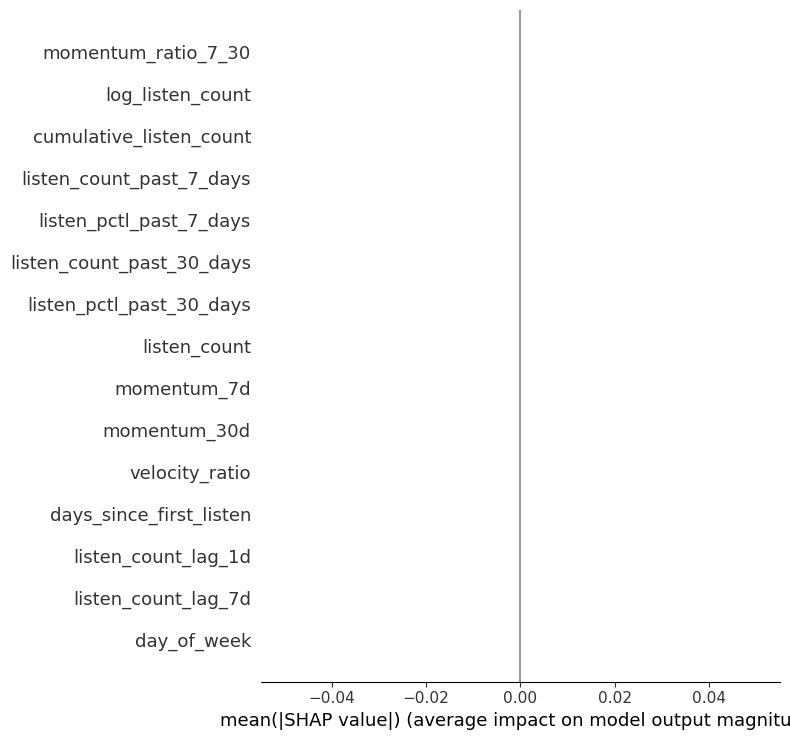


Artist — 30d Classifier


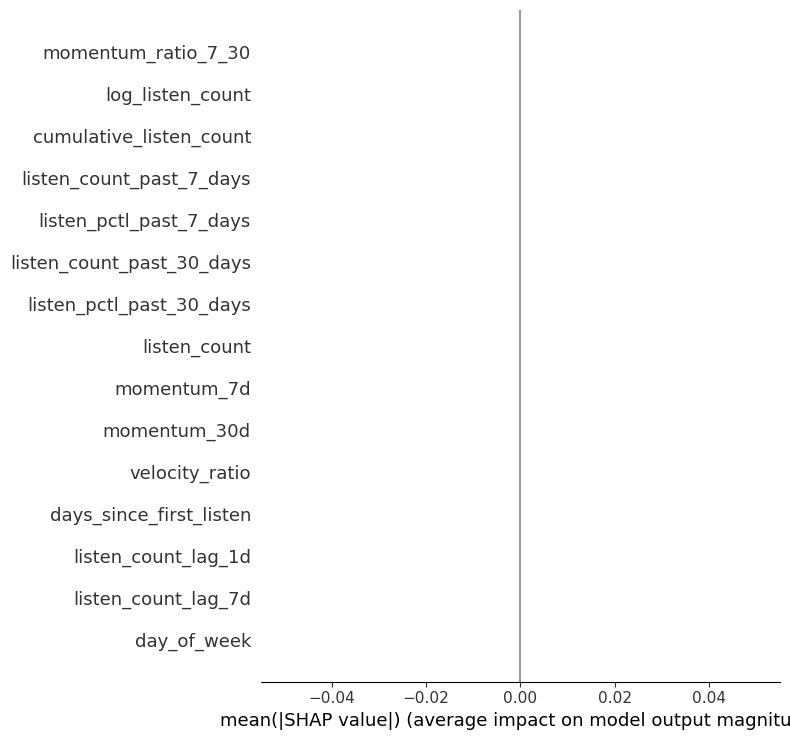


Track — 7d Classifier


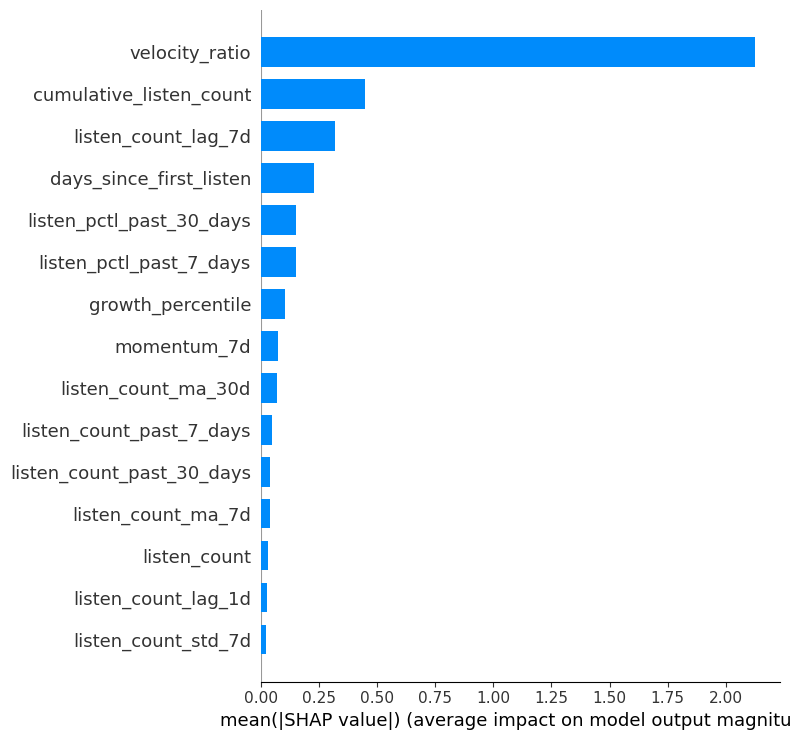


Track — 30d Classifier


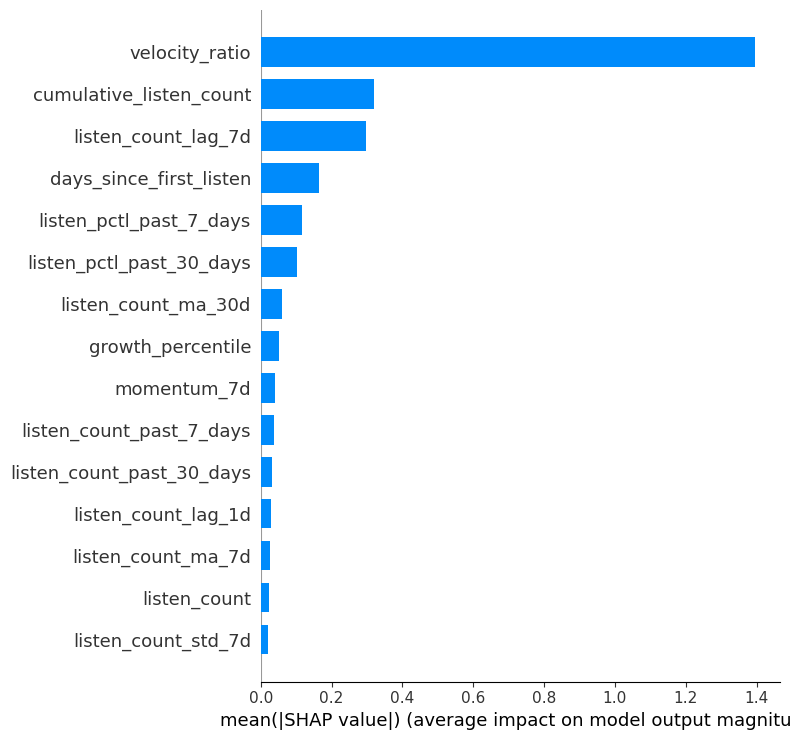

In [127]:
for entity, train_df, _, feat_cols in configs:
    for horizon in ["7d", "30d"]:
        key = (entity, horizon, "clf")
        if key not in xgb_results:
            continue

        model, met, _ = xgb_results[key]
        if model is None or not met:
            print(f"Skipping SHAP for {entity}-{horizon}: model missing or invalid metrics.")
            continue

        if len(train_df) == 0 or len(feat_cols) == 0:
            print(f"Skipping SHAP for {entity}-{horizon}: empty train/features.")
            continue

        X_sample = train_df[feat_cols].fillna(0).sample(n=min(500, len(train_df)), random_state=42)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_sample)

        print(f"\n{entity.title()} — {horizon} Classifier")
        shap.summary_plot(shap_vals, X_sample, plot_type="bar", max_display=15, show=True)

## Phase 3 — LSTM Sequence Models (PyTorch)

Build sliding-window sequences (T=30 past days → predict label) for each entity. Train LSTM networks for both classification and regression targets.

In [128]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")

PyTorch device: cpu


In [129]:
SEQ_LEN = 30  # Past days used as input sequence

class TimeSeriesDataset(Dataset):
    """Sliding-window dataset: (SEQ_LEN, n_features) → target scalar."""

    def __init__(self, df, id_col, feature_cols, target_col, seq_len=SEQ_LEN):
        self.sequences = []
        self.targets = []

        for _, group in df.groupby(id_col):
            group = group.sort_values("day")
            X = group[feature_cols].fillna(0).values.astype(np.float32)
            y = group[target_col].values.astype(np.float32)

            for i in range(seq_len, len(group)):
                self.sequences.append(X[i - seq_len : i])
                self.targets.append(y[i])

        self.sequences = np.array(self.sequences)  # (N, T, F)
        self.targets = np.array(self.targets)       # (N,)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.targets[idx], dtype=torch.float32),
        )


class PopularityLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2, task="clf"):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden_size, 1)
        self.task = task

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        _, (h_n, _) = self.lstm(x)
        out = self.head(h_n[-1])  # last layer's hidden state
        return out.squeeze(-1)

print(f"TimeSeriesDataset and PopularityLSTM defined (SEQ_LEN={SEQ_LEN})")

TimeSeriesDataset and PopularityLSTM defined (SEQ_LEN=30)


In [130]:
def train_lstm(train_df, test_df, id_col, feature_cols, target_col,
               task="clf", epochs=30, batch_size=256, lr=1e-3):
    """
    Train an LSTM model. task='clf' uses BCEWithLogitsLoss, task='reg' uses MSELoss.
    Returns (model, metrics_dict, test_preds).
    """
    if len(feature_cols) == 0:
        print("  ⚠ No features — skipping")
        return None, {}, np.array([])

    train_ds = TimeSeriesDataset(train_df, id_col, feature_cols, target_col)
    test_ds = TimeSeriesDataset(test_df, id_col, feature_cols, target_col)
    print(f"  Train sequences: {len(train_ds):,}  Test sequences: {len(test_ds):,}")

    if len(train_ds) == 0 or len(test_ds) == 0:
        print("  ⚠ Not enough sequences — skipping")
        return None, {}, np.array([])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    n_features = train_ds.sequences.shape[2]
    model = PopularityLSTM(n_features, task=task).to(device)

    if task == "clf":
        # Handle class imbalance with pos_weight
        pos_rate = float(train_ds.targets.mean())
        if pos_rate <= 0 or pos_rate >= 1:
            print("  ⚠ Training target has a single class — skipping")
            return None, {}, np.array([])
        pos_weight = torch.tensor([(1 - pos_rate) / max(pos_rate, 1e-6)], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
        train_loss /= len(train_ds)

        # Validation on test set (for early stopping only)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                val_loss += criterion(out, y_batch).item() * len(y_batch)
        val_loss /= len(test_ds)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if patience_counter >= 10:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            if task == "clf":
                out = torch.sigmoid(out)
            all_preds.append(out.cpu().numpy())
            all_targets.append(y_batch.numpy())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    metrics = {}
    if task == "clf":
        decision_threshold, _ = _best_f1_threshold(targets, preds)
        binary_preds = (preds >= decision_threshold).astype(int)

        has_two_classes = len(np.unique(targets)) > 1
        test_pos_count = int(targets.sum())
        test_size = int(len(targets))
        test_neg_count = int(test_size - test_pos_count)
        train_pos_rate = float(train_ds.targets.mean())

        roc_auc = roc_auc_score(targets, preds) if has_two_classes else float("nan")
        pr_auc = average_precision_score(targets, preds) if test_pos_count > 0 else float("nan")

        baseline_prob = np.full(len(targets), train_pos_rate)
        baseline_pr_auc = average_precision_score(targets, baseline_prob) if test_pos_count > 0 else float("nan")
        baseline_binary = (baseline_prob >= decision_threshold).astype(int)
        baseline_f1 = f1_score(targets, baseline_binary, zero_division=0)

        f1 = f1_score(targets, binary_preds, zero_division=0)
        precision = precision_score(targets, binary_preds, zero_division=0)
        recall = recall_score(targets, binary_preds, zero_division=0)

        metrics = {
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "decision_threshold": decision_threshold,
            "train_pos_rate": train_pos_rate,
            "test_pos_rate": float(targets.mean()) if len(targets) > 0 else float("nan"),
            "test_pos_count": test_pos_count,
            "test_neg_count": test_neg_count,
            "test_size": test_size,
            "baseline_pr_auc": baseline_pr_auc,
            "pr_auc_gain": (pr_auc - baseline_pr_auc) if not np.isnan(pr_auc) and not np.isnan(baseline_pr_auc) else float("nan"),
            "baseline_f1": baseline_f1,
            "f1_gain": f1 - baseline_f1,
        }

        print(
            f"  Test: AUC={metrics['roc_auc']:.4f}  AP={metrics['pr_auc']:.4f}  "
            f"F1={metrics['f1']:.4f}  Prec={metrics['precision']:.4f}  Rec={metrics['recall']:.4f}  "
            f"th={metrics['decision_threshold']:.2f}"
        )
        print(
            f"  Baseline: AP={metrics['baseline_pr_auc']:.4f}  AP_gain={metrics['pr_auc_gain']:.4f}  "
            f"F1_gain={metrics['f1_gain']:.4f}"
        )
    else:
        rmse = np.sqrt(mean_squared_error(targets, preds))
        mae = mean_absolute_error(targets, preds)

        baseline_pred = np.full(len(targets), float(train_ds.targets.mean()))
        baseline_rmse = np.sqrt(mean_squared_error(targets, baseline_pred))
        baseline_mae = mean_absolute_error(targets, baseline_pred)

        binary_preds = (preds >= 0.95).astype(int)
        binary_targets = (targets >= 0.95).astype(int)
        baseline_binary = (baseline_pred >= 0.95).astype(int)

        has_two_binary = len(np.unique(binary_targets)) > 1
        test_pos_count = int(binary_targets.sum())

        roc_auc_thresholded = roc_auc_score(binary_targets, preds) if has_two_binary else float("nan")
        pr_auc_thresholded = average_precision_score(binary_targets, preds) if test_pos_count > 0 else float("nan")
        baseline_pr_auc_thresholded = average_precision_score(binary_targets, baseline_pred) if test_pos_count > 0 else float("nan")

        f1_thresholded = f1_score(binary_targets, binary_preds, zero_division=0)
        baseline_f1_thresholded = f1_score(binary_targets, baseline_binary, zero_division=0)

        metrics = {
            "rmse": rmse,
            "mae": mae,
            "baseline_rmse": baseline_rmse,
            "baseline_mae": baseline_mae,
            "rmse_improvement": baseline_rmse - rmse,
            "mae_improvement": baseline_mae - mae,
            "roc_auc_thresholded": roc_auc_thresholded,
            "pr_auc_thresholded": pr_auc_thresholded,
            "baseline_pr_auc_thresholded": baseline_pr_auc_thresholded,
            "pr_auc_gain": (
                pr_auc_thresholded - baseline_pr_auc_thresholded
                if not np.isnan(pr_auc_thresholded) and not np.isnan(baseline_pr_auc_thresholded)
                else float("nan")
            ),
            "f1_thresholded": f1_thresholded,
            "baseline_f1_thresholded": baseline_f1_thresholded,
            "f1_gain": f1_thresholded - baseline_f1_thresholded,
            "test_pos_count": test_pos_count,
        }

        print(
            f"  Test: RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  "
            f"th-AUC={metrics['roc_auc_thresholded']:.4f}  th-AP={metrics['pr_auc_thresholded']:.4f}"
        )
        print(
            f"  Baseline: RMSE={metrics['baseline_rmse']:.4f}  RMSE_gain={metrics['rmse_improvement']:.4f}  "
            f"th-AP_gain={metrics['pr_auc_gain']:.4f}"
        )

    return model, metrics, preds


print("train_lstm() defined")

train_lstm() defined


### Train all LSTM models
Same structure as XGBoost: Artist/Track × 7d/30d × Classifier/Regressor

In [ ]:
lstm_results = {}  # key: (entity, horizon, model_type) → (model, metrics, preds)

raw_lstm_configs = [
    ("artist", art_train, art_test, "artist_mbid", art_features),
    ("track",  trk_train, trk_test, "recording_id", trk_features),
]

# Align with XGBoost filtering so downstream comparison/plots stay consistent.
lstm_configs = []
for entity, train_df, test_df, id_col, feat_cols in raw_lstm_configs:
    if len(train_df) == 0 or len(test_df) == 0 or len(feat_cols) == 0:
        print(f"Skipping {entity}: empty train/test or no features.")
        continue
    lstm_configs.append((entity, train_df, test_df, id_col, feat_cols))

for entity, train_df, test_df, id_col, feat_cols in lstm_configs:
    for horizon in ["7d", "30d"]:
        clf_target = f"is_popular_{horizon}"
        reg_target = f"future_growth_pctl_{horizon}"

        print(f"\n{'='*60}")
        print(f"LSTM Classifier — {entity} — {horizon}")
        print(f"{'='*60}")
        m, met, preds = train_lstm(train_df, test_df, id_col, feat_cols, clf_target, task="clf")
        lstm_results[(entity, horizon, "clf")] = (m, met, preds)

        print(f"\nLSTM Regressor — {entity} — {horizon}")
        print(f"{'-'*60}")
        m, met, preds = train_lstm(train_df, test_df, id_col, feat_cols, reg_target, task="reg")
        lstm_results[(entity, horizon, "reg")] = (m, met, preds)

print(f"\nTrained {len(lstm_results)} LSTM models.")


LSTM Classifier — artist — 7d
  Train sequences: 0  Test sequences: 0
  ⚠ Not enough sequences — skipping

LSTM Regressor — artist — 7d
------------------------------------------------------------
  Train sequences: 0  Test sequences: 0
  ⚠ Not enough sequences — skipping

LSTM Classifier — artist — 30d
  Train sequences: 0  Test sequences: 0
  ⚠ Not enough sequences — skipping

LSTM Regressor — artist — 30d
------------------------------------------------------------
  Train sequences: 0  Test sequences: 0
  ⚠ Not enough sequences — skipping

LSTM Classifier — track — 7d
  Train sequences: 223,300  Test sequences: 2,626
  Epoch   1: train_loss=7.3074  val_loss=0.0005
  Epoch   5: train_loss=7.7275  val_loss=0.0002
  Epoch  10: train_loss=7.6741  val_loss=0.0003
  Epoch  15: train_loss=4.3650  val_loss=0.0002
  Epoch  20: train_loss=3.9479  val_loss=0.0001
  Epoch  25: train_loss=4.6082  val_loss=0.0000
  Epoch  30: train_loss=0.6745  val_loss=0.0000
  Test: AUC=nan  AP=nan  F1=0.0000

## Phase 4 — Evaluation & Comparison

Side-by-side metrics table, ROC curves, precision-recall curves, and top-N predicted rising entities vs actuals.

In [ ]:
# Build comparison metrics table with reliability + baseline checks
rows = []
for key_set, label in [(xgb_results, "XGBoost"), (lstm_results, "LSTM")]:
    for (entity, horizon, mtype), (_, metrics, _) in key_set.items():
        if not metrics:
            continue
        row = {"Model": label, "Entity": entity, "Horizon": horizon, "Type": mtype}
        row.update(metrics)
        rows.append(row)

metrics_df = pd.DataFrame(rows)

if metrics_df.empty:
    print("No metrics available yet. Run training cells first.")
else:
    # Reliability: classifier evaluation is unreliable with too few positives/negatives in test.
    metrics_df["evaluation_reliable"] = True
    clf_mask = metrics_df["Type"] == "clf"

    if {"test_pos_count", "test_neg_count"}.issubset(metrics_df.columns):
        metrics_df.loc[clf_mask, "evaluation_reliable"] = (
            (metrics_df.loc[clf_mask, "test_pos_count"].fillna(0) >= 10)
            & (metrics_df.loc[clf_mask, "test_neg_count"].fillna(0) >= 10)
        )
    elif "test_pos_count" in metrics_df.columns:
        metrics_df.loc[clf_mask, "evaluation_reliable"] = (
            metrics_df.loc[clf_mask, "test_pos_count"].fillna(0) >= 10
        )

    # Baseline pass criteria
    metrics_df["beats_baseline"] = False

    if "pr_auc_gain" in metrics_df.columns:
        metrics_df.loc[clf_mask, "beats_baseline"] = (
            metrics_df.loc[clf_mask, "pr_auc_gain"].fillna(-np.inf) > 0
        )

    reg_mask = metrics_df["Type"] == "reg"
    if "rmse_improvement" in metrics_df.columns:
        metrics_df.loc[reg_mask, "beats_baseline"] = (
            metrics_df.loc[reg_mask, "rmse_improvement"].fillna(-np.inf) > 0
        )

    metrics_df["status"] = np.where(
        metrics_df["evaluation_reliable"] & metrics_df["beats_baseline"],
        "PASS",
        "NEEDS_WORK",
    )

    display_cols = [
        "Model", "Entity", "Horizon", "Type", "status",
        "evaluation_reliable", "beats_baseline",
        "roc_auc", "pr_auc", "f1", "precision", "recall",
        "rmse", "mae",
        "baseline_pr_auc", "pr_auc_gain",
        "baseline_rmse", "rmse_improvement",
        "decision_threshold", "test_pos_count", "test_neg_count", "test_size",
    ]
    display_cols = [c for c in display_cols if c in metrics_df.columns]

    display(
        metrics_df[display_cols]
        .sort_values(["Model", "Entity", "Horizon", "Type"])
        .reset_index(drop=True)
        .round(4)
    )

    print("\nStatus summary:")
    print(metrics_df["status"].value_counts(dropna=False).to_string())

    unreliable = metrics_df[~metrics_df["evaluation_reliable"]]
    if len(unreliable) > 0:
        cols = [c for c in ["Model", "Entity", "Horizon", "Type", "test_pos_count", "test_neg_count", "test_size"] if c in unreliable.columns]
        print("\nUnreliable evaluations (insufficient class coverage in test):")
        print(unreliable[cols].to_string(index=False))

,Model,Entity,Horizon,Type,status,evaluation_reliable,beats_baseline,roc_auc,f1,precision,recall,rmse,mae
0,XGBoost,track,30d,clf,NEEDS_WORK,True,False,NaN,0.0,0.0,0.0,NaN,NaN
1,XGBoost,track,30d,reg,NEEDS_WORK,True,False,NaN,NaN,NaN,NaN,0.0715,0.0705
2,XGBoost,track,7d,clf,NEEDS_WORK,True,False,NaN,0.0,0.0,0.0,NaN,NaN
3,XGBoost,track,7d,reg,NEEDS_WORK,True,False,NaN,NaN,NaN,NaN,0.0987,0.0912



Status summary:
status
NEEDS_WORK    4


### ROC & Precision-Recall Curves (Classifiers only)

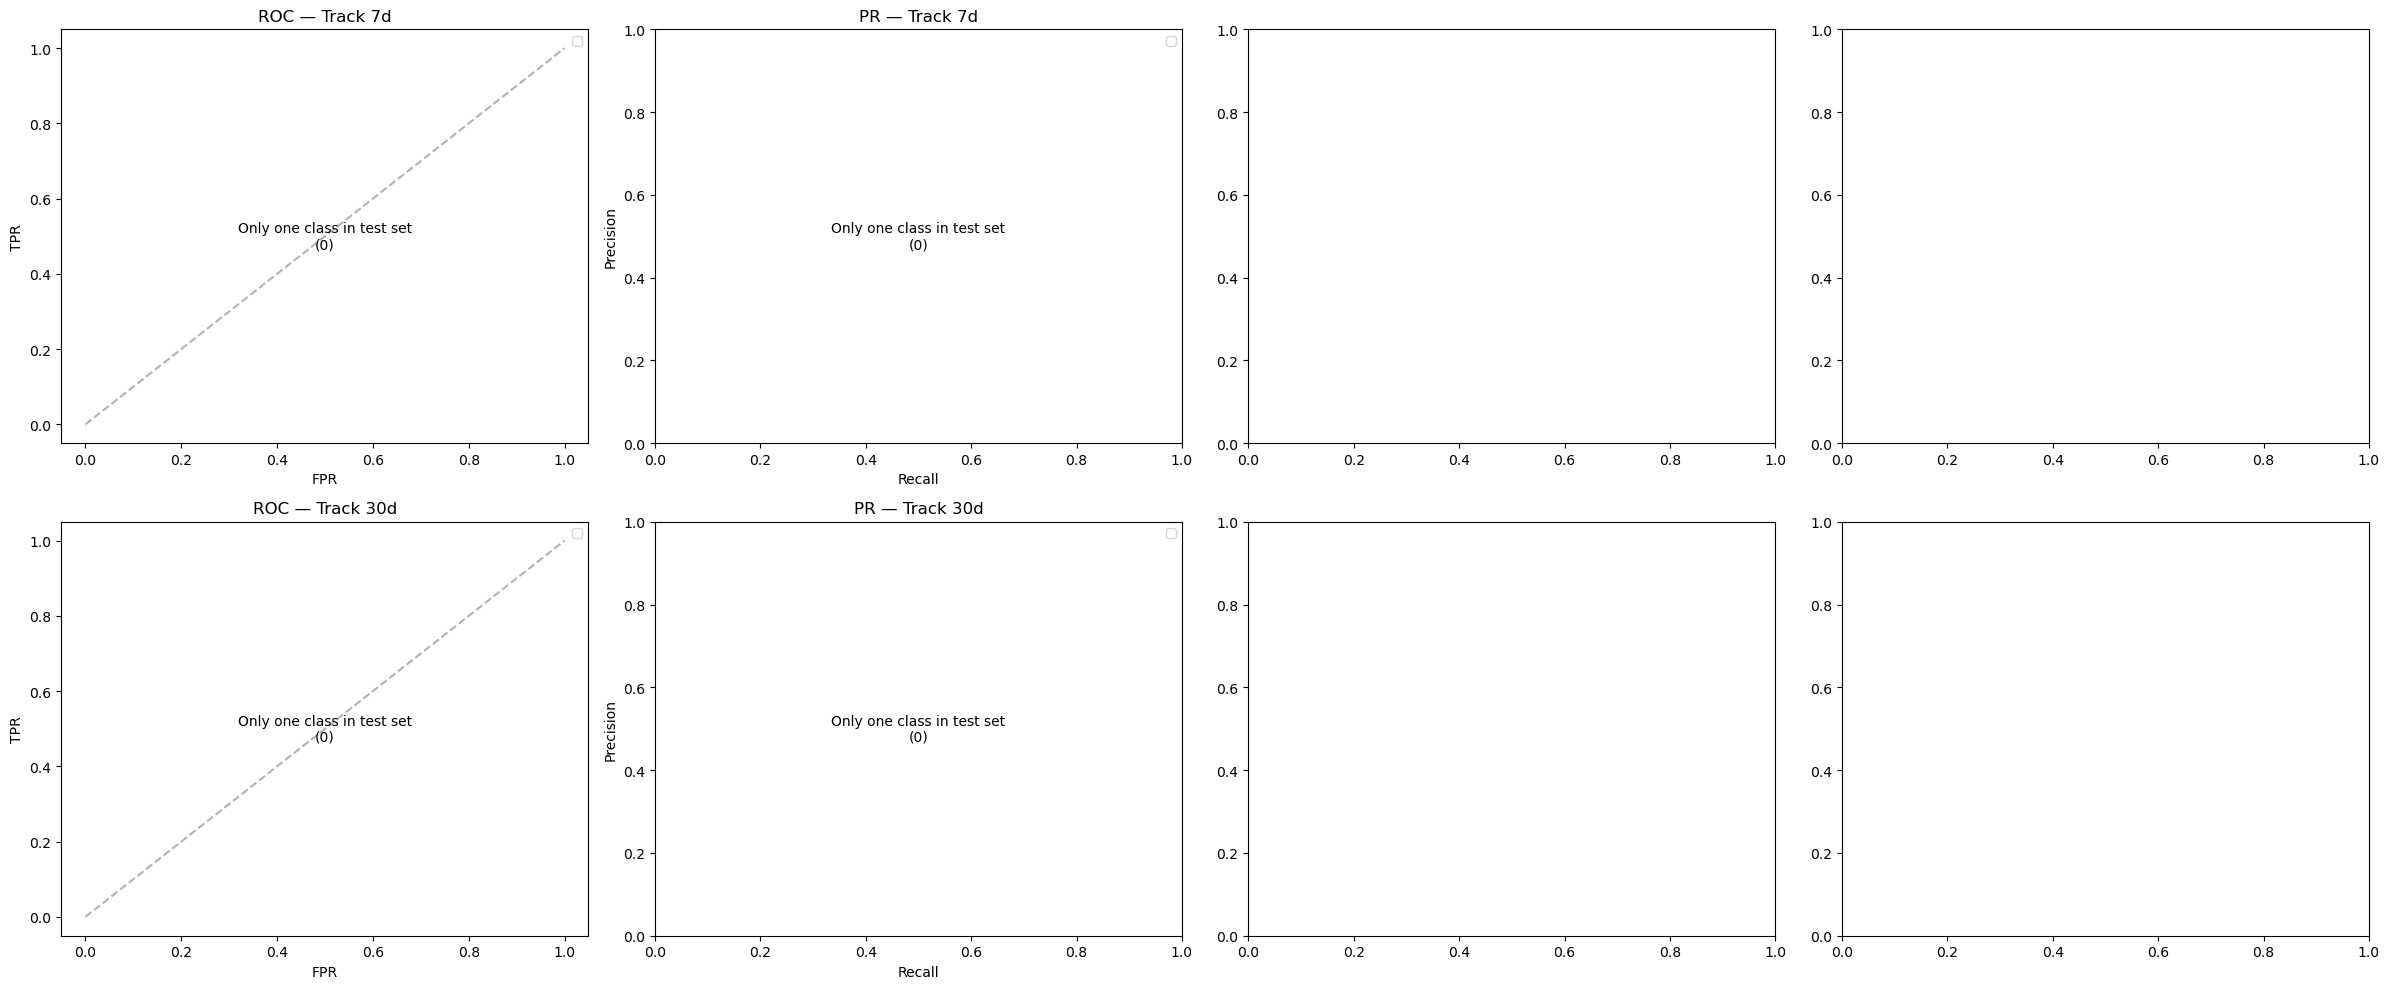

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for col_offset, (entity, _, test_df, feat_cols) in enumerate(configs):
    for row, horizon in enumerate(["7d", "30d"]):
        target_col = f"is_popular_{horizon}"

        # --- ROC ---
        ax_roc = axes[row][col_offset * 2]
        ax_roc.set_title(f"ROC — {entity.title()} {horizon}")
        ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3)

        # XGBoost
        xgb_proba = xgb_results[(entity, horizon, "clf")][2]
        xgb_y = test_df[target_col].values
        
        # Check if both classes present (need for ROC/AUC)
        n_classes = len(np.unique(xgb_y))
        if n_classes > 1:
            fpr, tpr, _ = roc_curve(xgb_y, xgb_proba)
            ax_roc.plot(fpr, tpr, label=f"XGB (AUC={roc_auc_score(xgb_y, xgb_proba):.3f})")
        else:
            ax_roc.text(0.5, 0.5, f"Only one class in test set\n({int(xgb_y[0])})", 
                       ha='center', va='center', transform=ax_roc.transAxes)

        lstm_preds = lstm_results[(entity, horizon, "clf")][2]
        if len(lstm_preds) > 0:
            # LSTM test set is smaller (seq_len trimming), build aligned targets
            id_col = "artist_mbid" if entity == "artist" else "recording_id"
            lstm_ds = TimeSeriesDataset(test_df, id_col, feat_cols, target_col)
            lstm_y = lstm_ds.targets
            
            if len(np.unique(lstm_y)) > 1:
                fpr2, tpr2, _ = roc_curve(lstm_y, lstm_preds)
                ax_roc.plot(fpr2, tpr2, label=f"LSTM (AUC={roc_auc_score(lstm_y, lstm_preds):.3f})")

        ax_roc.legend(fontsize=9)
        ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")

        # --- Precision-Recall ---
        ax_pr = axes[row][col_offset * 2 + 1]
        ax_pr.set_title(f"PR — {entity.title()} {horizon}")

        if n_classes > 1:
            prec, rec, _ = precision_recall_curve(xgb_y, xgb_proba)
            ax_pr.plot(rec, prec, label="XGB")
        else:
            ax_pr.text(0.5, 0.5, f"Only one class in test set\n({int(xgb_y[0])})", 
                      ha='center', va='center', transform=ax_pr.transAxes)

        if len(lstm_preds) > 0 and len(np.unique(lstm_y)) > 1:
            prec2, rec2, _ = precision_recall_curve(lstm_y, lstm_preds)
            ax_pr.plot(rec2, prec2, label="LSTM")

        ax_pr.legend(fontsize=9)
        ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")

plt.tight_layout()
plt.show()

### Top-N Predicted Rising Entities vs Actual
Show the top 20 entities predicted most likely to be "popular" and whether they actually were.

In [ ]:
TOP_N = 20

for entity, _, test_df, feat_cols in configs:
    id_col = "artist_mbid" if entity == "artist" else "recording_id"
    for horizon in ["7d", "30d"]:
        target_col = f"is_popular_{horizon}"
        proba = xgb_results[(entity, horizon, "clf")][2]

        result = test_df[[id_col, "day", target_col]].copy()
        result["xgb_score"] = proba
        # Aggregate: mean predicted score per entity
        entity_scores = (
            result.groupby(id_col)
            .agg(
                mean_xgb_score=("xgb_score", "mean"),
                actually_popular=(target_col, "max"),
                n_days=("day", "count"),
            )
            .sort_values("mean_xgb_score", ascending=False)
            .head(TOP_N)
        )
        hit_rate = entity_scores["actually_popular"].mean()
        print(f"\n{entity.title()} — {horizon}: Top {TOP_N} predicted (hit rate: {100*hit_rate:.0f}%)")
        display(entity_scores.round(4))


Track — 7d: Top 20 predicted (hit rate: 0%)


,mean_xgb_score,actually_popular,n_days
recording_id,,,
_Снег в моей душе,0.2968,0,1
_Новый год,0.1589,0,6
_Retry Now,0.1521,0,3



Track — 30d: Top 20 predicted (hit rate: 0%)


,mean_xgb_score,actually_popular,n_days
recording_id,,,
_Снег в моей душе,0.1350,0,1
_Retry Now,0.0377,0,3
_Новый год,0.0279,0,6
